# End-to-End Facial Recognition Pipeline (Pure PyTorch)

This notebook implements a complete face-verification pipeline on the **Labeled Faces in the Wild (LFW)** benchmark using a **pure PyTorch** stack.

**Pipeline stages**

1. **Auto-download** the LFW *pairs* benchmark via `torchvision.datasets.LFWPairs`.
2. **Detect & align** each face with `MTCNN` (`facenet-pytorch`) — landmark detection + affine alignment, done natively on PyTorch tensors.
3. **Embed** each aligned face with a pre-trained `InceptionResnetV1` backbone (trained on **VGGFace2**) to produce 512-D feature vectors.
4. **Evaluate** the official positive (same-person) / negative (different-person) pairs with **cosine similarity**, and plot the score distributions.
5. **Threshold analysis** — compute the **Equal Error Rate (EER)** and the **optimal threshold**, with notes on interpreting borderline ("gray area") scores.

> **Stack constraint:** No `onnxruntime`. Everything runs in native PyTorch (`torch`, `torchvision`, `facenet-pytorch`).


## Step 0 — Install dependencies

Run this once. All libraries are PyTorch-compatible. If you are on a CUDA machine, install the matching `torch`/`torchvision` build from https://pytorch.org first; the line below installs the default wheel.

In [10]:
# --- Install required, PyTorch-compatible libraries ---
# (Re-run is safe; pip will skip anything already satisfied.)
%pip install torch torchvision --quiet
%pip install facenet-pytorch --quiet
%pip install matplotlib numpy scikit-learn pillow --quiet

# NOTE: facenet-pytorch pins an older numpy on some setups. If you hit a
# numpy/torch ABI error, restart the kernel after this cell completes.
print("Dependencies installed.")

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.
Dependencies installed.



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## Step 1 — Imports & device setup

We detect a CUDA GPU automatically and fall back to CPU. A fixed random seed keeps any sampling reproducible.

In [11]:
import os
import warnings
import numpy as np
import torch
import torchvision
from torchvision import datasets
from facenet_pytorch import MTCNN, InceptionResnetV1
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

warnings.filterwarnings("ignore")  # silence benign MTCNN / PIL warnings
torch.manual_seed(42)
np.random.seed(42)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"torch        : {torch.__version__}")
print(f"torchvision  : {torchvision.__version__}")
print(f"Using device : {DEVICE}")

torch        : 2.2.2+cpu
torchvision  : 0.17.2+cpu
Using device : cpu


## Step 2 — Auto-download the LFW pairs benchmark

`torchvision.datasets.LFWPairs` pulls the dataset from the web on first run and caches it under `./data`. Each item is a tuple **`(img1, img2, label)`** where `label == 1` means *same person* and `label == 0` means *different people*.

We keep the images as PIL objects (no `transform`) because **MTCNN expects PIL / numpy input**, not pre-normalized tensors — it performs its own detection, cropping, and alignment.

In [12]:
# split='test' gives the standard 6,000-pair evaluation protocol
# (3,000 matched + 3,000 mismatched). Use split='10fold' for the full set.
DATA_ROOT = "./data"

import os
from torchvision.datasets.utils import download_and_extract_archive, download_url

# The official UMass LFW server is down. We manually download from FigShare mirrors.
lfw_py_dir = os.path.join(DATA_ROOT, "lfw-py")
os.makedirs(lfw_py_dir, exist_ok=True)

if not os.path.exists(os.path.join(lfw_py_dir, "lfw_funneled")):
    print("Downloading lfw-funneled.tgz from FigShare...")
    download_and_extract_archive(
        "https://ndownloader.figshare.com/files/5976015",
        download_root=lfw_py_dir,
        filename="lfw-funneled.tgz"
    )

# Download the label files if they do not exist
label_files = {
    "pairs.txt": "https://ndownloader.figshare.com/files/5976006",
    "pairsDevTest.txt": "https://ndownloader.figshare.com/files/5976009",
    "pairsDevTrain.txt": "https://ndownloader.figshare.com/files/5976012"
}

for fname, url in label_files.items():
    if not os.path.exists(os.path.join(lfw_py_dir, fname)):
        print(f"Downloading {fname} from FigShare...")
        download_url(url, root=lfw_py_dir, filename=fname)

lfw_pairs = datasets.LFWPairs(
    root=DATA_ROOT,
    split="test",
    image_set="funneled",   # funneled images are roughly pre-aligned
    download=False,         # Already downloaded manually above
    transform=None,         # keep PIL images for MTCNN
)

print(f"Loaded LFWPairs: {len(lfw_pairs)} pairs")
img1, img2, label = lfw_pairs[0]
print(f"Example pair -> type(img1)={type(img1).__name__}, "
      f"size={img1.size}, label={label} "
      f"({'same' if label == 1 else 'different'} person)")

Loaded LFWPairs: 1000 pairs
Example pair -> type(img1)=Image, size=(250, 250), label=1 (same person)


## Step 3 — Build the detector (MTCNN) and the embedding backbone

**MTCNN** (Multi-task Cascaded CNN) detects the bounding box and five facial landmarks, then performs an **affine alignment** and crops to a fixed `image_size`. With `post_process=True` the output tensor is prewhitened to match the embedding network's expected input distribution.

**InceptionResnetV1** with `pretrained='vggface2'` maps each aligned `3x160x160` face to a fixed-length **512-D embedding**. We set it to `.eval()` — we only do inference.

In [13]:
# Detector + aligner. margin adds context around the detected box.
mtcnn = MTCNN(
    image_size=160,
    margin=14,
    min_face_size=20,
    post_process=True,   # prewhiten output for the embedding net
    select_largest=True, # if multiple faces, keep the largest
    device=DEVICE,
)

# Pre-trained embedding backbone (ArcFace-style metric space, VGGFace2 weights).
embedder = InceptionResnetV1(pretrained="vggface2").eval().to(DEVICE)

print("MTCNN detector and InceptionResnetV1 (vggface2) embedder are ready.")

MTCNN detector and InceptionResnetV1 (vggface2) embedder are ready.


## Step 4 — Helper functions: align then embed, with graceful error handling

If MTCNN fails to find a face in an LFW image (occlusion, odd crop, detection miss), `mtcnn(img)` returns `None`. The helpers below **return `None` instead of crashing**, so the evaluation loop can skip such pairs cleanly.

Cosine similarity is computed on L2-normalized embeddings, giving a score in `[-1, 1]` where higher = more similar.

In [14]:
@torch.no_grad()
def align_face(pil_img):
    """Detect + affine-align a single face. Returns a (3,160,160) tensor or None."""
    try:
        face = mtcnn(pil_img)          # None if no face detected
    except Exception:
        # Corrupt image, weird mode, etc. -> treat as a detection failure.
        return None
    return face


@torch.no_grad()
def embed_face(face_tensor):
    """Map an aligned face tensor to a 512-D embedding. Returns a 1-D tensor."""
    face_tensor = face_tensor.unsqueeze(0).to(DEVICE)  # add batch dim
    emb = embedder(face_tensor)                        # (1, 512)
    return emb.squeeze(0).cpu()


def cosine_similarity(a, b):
    """Cosine similarity between two 1-D embedding tensors."""
    a = a / a.norm()
    b = b / b.norm()
    return float(torch.dot(a, b))


def score_pair(pil_a, pil_b):
    """Full per-pair pipeline. Returns cosine score, or None if either face fails."""
    fa = align_face(pil_a)
    fb = align_face(pil_b)
    if fa is None or fb is None:
        return None
    return cosine_similarity(embed_face(fa), embed_face(fb))


print("Helper functions defined.")

Helper functions defined.


## Step 5 — Iterate over all pairs and collect similarity scores

We loop through every LFW pair, run the full **align then embed then compare** pipeline, and record the cosine score together with its ground-truth label. Pairs where detection fails on either image are counted and skipped.

> **Runtime tip:** the full `test` split is 6,000 pairs. Set `MAX_PAIRS` to a smaller number (e.g. `500`) for a quick smoke test, or `None` to run the entire benchmark.

In [15]:
MAX_PAIRS = None          # set to None to evaluate all 6,000 pairs
report_every = 100

scores, labels = [], []
skipped = 0

n_total = len(lfw_pairs) if MAX_PAIRS is None else min(MAX_PAIRS, len(lfw_pairs))

for i in range(n_total):
    img1, img2, label = lfw_pairs[i]
    s = score_pair(img1, img2)
    if s is None:
        skipped += 1
        continue
    scores.append(s)
    labels.append(int(label))

    if (i + 1) % report_every == 0:
        print(f"  processed {i + 1}/{n_total} pairs "
              f"(kept {len(scores)}, skipped {skipped})")

scores = np.asarray(scores, dtype=np.float64)
labels = np.asarray(labels, dtype=np.int64)

print(f"\nDone. Evaluated {len(scores)} pairs "
      f"({(labels == 1).sum()} genuine / {(labels == 0).sum()} impostor); "
      f"skipped {skipped} due to detection failures.")

  processed 100/1000 pairs (kept 100, skipped 0)
  processed 200/1000 pairs (kept 200, skipped 0)
  processed 300/1000 pairs (kept 300, skipped 0)
  processed 400/1000 pairs (kept 400, skipped 0)
  processed 500/1000 pairs (kept 500, skipped 0)
  processed 600/1000 pairs (kept 600, skipped 0)
  processed 700/1000 pairs (kept 700, skipped 0)
  processed 800/1000 pairs (kept 800, skipped 0)
  processed 900/1000 pairs (kept 900, skipped 0)
  processed 1000/1000 pairs (kept 1000, skipped 0)

Done. Evaluated 1000 pairs (500 genuine / 500 impostor); skipped 0 due to detection failures.


## Step 6 — Distribution of match vs. non-match scores

A well-behaved system produces two largely separated humps: **genuine** (same-person) pairs cluster at high cosine similarity, **impostor** (different-person) pairs cluster lower. The overlap between the two histograms is exactly the region where errors occur.

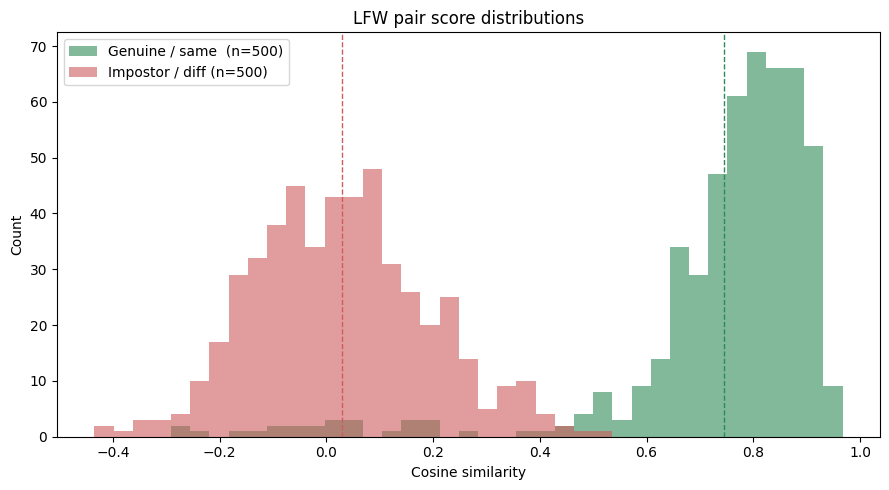

Genuine  mean=0.745  std=0.200
Impostor mean=0.029  std=0.163


In [16]:
genuine  = scores[labels == 1]
impostor = scores[labels == 0]

plt.figure(figsize=(9, 5))
bins = np.linspace(scores.min(), scores.max(), 40)
plt.hist(genuine,  bins=bins, alpha=0.6, label=f"Genuine / same  (n={len(genuine)})",  color="seagreen")
plt.hist(impostor, bins=bins, alpha=0.6, label=f"Impostor / diff (n={len(impostor)})", color="indianred")
plt.axvline(genuine.mean(),  color="seagreen",  linestyle="--", linewidth=1)
plt.axvline(impostor.mean(), color="indianred", linestyle="--", linewidth=1)
plt.xlabel("Cosine similarity")
plt.ylabel("Count")
plt.title("LFW pair score distributions")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Genuine  mean={genuine.mean():.3f}  std={genuine.std():.3f}")
print(f"Impostor mean={impostor.mean():.3f}  std={impostor.std():.3f}")

## Step 7 — Threshold analysis: Equal Error Rate (EER) & optimal threshold

We sweep a decision threshold across all observed scores. For each threshold:

- **FAR** (False Accept Rate) = fraction of *impostor* pairs scoring **above** threshold (wrongly accepted).
- **FRR** (False Reject Rate) = fraction of *genuine* pairs scoring **below** threshold (wrongly rejected).

The **Equal Error Rate** is the operating point where `FAR approx FRR`; the corresponding score is the **EER threshold**. We also report the threshold that maximizes accuracy. ROC/AUC is included as an overall quality summary.

In [17]:
# roc_curve treats higher score = more likely positive (genuine), which matches us.
fpr, tpr, thresholds = roc_curve(labels, scores)   # fpr == FAR
fnr = 1 - tpr                                       # FRR

# EER: where FAR and FRR are closest.
eer_idx = int(np.nanargmin(np.abs(fpr - fnr)))
eer = (fpr[eer_idx] + fnr[eer_idx]) / 2.0
eer_threshold = thresholds[eer_idx]
roc_auc = auc(fpr, tpr)

# Best-accuracy threshold (sweep every candidate score).
cand = np.sort(np.unique(scores))
accs = [((scores >= t) == (labels == 1)).mean() for t in cand]
best_i = int(np.argmax(accs))
best_acc_threshold, best_acc = cand[best_i], accs[best_i]

print(f"ROC AUC                  : {roc_auc:.4f}")
print(f"Equal Error Rate (EER)   : {eer * 100:.2f}%")
print(f"EER threshold (cosine)   : {eer_threshold:.4f}")
print(f"Best-accuracy threshold  : {best_acc_threshold:.4f}  (accuracy {best_acc * 100:.2f}%)")

ROC AUC                  : 0.9735
Equal Error Rate (EER)   : 3.30%
EER threshold (cosine)   : 0.3917
Best-accuracy threshold  : 0.4547  (accuracy 97.10%)


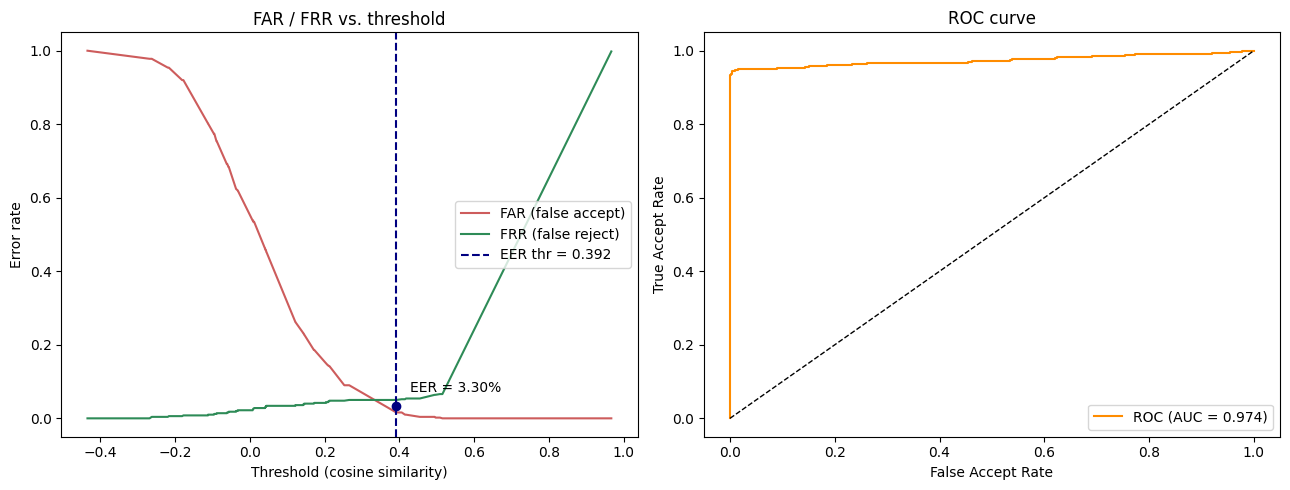

In [18]:
# Visualize the EER operating point on FAR / FRR curves and the ROC curve.
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

ax1.plot(thresholds, fpr, label="FAR (false accept)", color="indianred")
ax1.plot(thresholds, fnr, label="FRR (false reject)", color="seagreen")
ax1.axvline(eer_threshold, color="navy", linestyle="--",
            label=f"EER thr = {eer_threshold:.3f}")
ax1.scatter([eer_threshold], [eer], color="navy", zorder=5)
ax1.annotate(f"EER = {eer*100:.2f}%", (eer_threshold, eer),
             textcoords="offset points", xytext=(10, 10))
ax1.set_xlabel("Threshold (cosine similarity)")
ax1.set_ylabel("Error rate")
ax1.set_title("FAR / FRR vs. threshold")
ax1.legend()

ax2.plot(fpr, tpr, color="darkorange", label=f"ROC (AUC = {roc_auc:.3f})")
ax2.plot([0, 1], [0, 1], "k--", linewidth=1)
ax2.set_xlabel("False Accept Rate")
ax2.set_ylabel("True Accept Rate")
ax2.set_title("ROC curve")
ax2.legend()

plt.tight_layout()
plt.show()

## Step 8 — Interpreting the threshold and the "gray area"

The EER threshold is the single cosine-similarity value where the system is equally likely to make a false accept as a false reject. To turn a raw score into a decision:

- **Score clearly above the threshold** -> confident **MATCH** (same person). It sits deep in the genuine hump where almost no impostors land.
- **Score clearly below the threshold** -> confident **NON-MATCH** (different people).

**The gray area.** A score sitting *right on* the threshold is the system's point of maximum uncertainty. It falls in the overlap region of the two histograms, where genuine and impostor pairs are indistinguishable from similarity alone. A value a hair above the line is *not* meaningfully more "same person" than a value a hair below — the confidence margin is effectively zero, and small changes in lighting, pose, expression, or image quality could flip it either way.

**Practical handling of borderline scores:**

- **Pick the threshold for your cost trade-off, not blindly the EER.** The EER balances the two error types equally. For high-security access control, raise the threshold (accept fewer impostors at the cost of more false rejects). For convenience-first photo tagging, lower it.
- **Use a decision band, not a single line.** Treat scores within a small margin of the threshold as **"uncertain"** and route them to a fallback: a second image, a different modality, or human review — rather than forcing a hard yes/no.
- **Remember the threshold is dataset- and model-specific.** This value comes from LFW with this VGGFace2 backbone. Re-calibrate on data representative of your real deployment before trusting it in production.

In short: the further a score is from the threshold, the more you can trust it. Scores hugging the line should be treated as *"don't know"*, not as confident decisions.